# Cats vs Dogs Classification with CNN

This notebook demonstrates the process of building a Convolutional Neural Network (CNN) for classifying images of cats and dogs. The notebook is organized into three main sections:

1. **Dataset Exploration**: Examining the dataset, visualizing images, and analyzing their properties
2. **Data Preprocessing**: Setting up data augmentation and preprocessing pipelines
3. **CNN Model**: Building, training, and evaluating a simple CNN model

## Setup and Imports


In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from pathlib import Path
import pandas as pd
from PIL import Image
import imagesize
import torch.nn as nn
import torch.nn.functional as F
import itertools
from time import perf_counter
import os
import shutil
import glob
import matplotlib.pyplot as plt
import warnings
import random
from sklearn.metrics import confusion_matrix, classification_report

warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Number of CUDA devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"CUDA Device {i}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA is not available. ")

print("Using device:", device)

PyTorch version: 2.3.1+cu121
CUDA available: True
CUDA version: 12.1
Number of CUDA devices: 1
CUDA Device 0: NVIDIA GeForce RTX 3090
Using device: cuda


In [2]:
# cuDNN tweak only if available
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.benchmark = True         # speed up convs for fixed image size
torch.set_float32_matmul_precision("high")      # small speedup on Ampere+

#Organize data into train, test and validation sets
notebook_dir = Path.cwd() #get current notebook dir

data_folder = notebook_dir.parent / "data" #create path to data folder

#create folders inside data
dirs = [
    "train/dog", "train/cat",
    "valid/dog", "valid/cat",
    "test/dog",  "test/cat"
]

for d in dirs:
    (data_folder / d).mkdir(parents=True, exist_ok=True)


# --- Source folders ---
cat_src = data_folder / "Cat"
dog_src = data_folder / "Dog"

# --- Split sizes per class ---
N_TRAIN, N_VALID, N_TEST = 500, 100, 100

# Optional: if we want to *clear* target split folders before re-filling, set to True
FORCE_CLEAN = False

def list_images(folder: Path):
    # support .jpg and .jpeg
    return sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")))

def existing_basenames(dst_folder: Path):
    # what is already there (avoid duplicates on re-run)
    exts = ("*.jpg", "*.jpeg")
    return {p.name for ext in exts for p in dst_folder.glob(ext)}

def copy_unique(files, dst_folder: Path, max_n: int):
    dst_folder.mkdir(parents=True, exist_ok=True)
    have = existing_basenames(dst_folder)
    to_copy = [p for p in files if p.name not in have]
    k = min(max_n - len(have), len(to_copy))
    for p in to_copy[:max(0, k)]:
        shutil.copy2(str(p), str(dst_folder))
    return max(0, k)

def maybe_clean_targets():
    if not FORCE_CLEAN:
        return
    for d in dirs:
        tgt = data_folder / d
        for p in tgt.glob("*.jpg"):
            p.unlink(missing_ok=True)
        for p in tgt.glob("*.jpeg"):
            p.unlink(missing_ok=True)

maybe_clean_targets()

rng = random.Random(SEED)  # deterministic split

def split_and_copy_one_class(src: Path, cls_name: str):
    imgs = list_images(src)
    if not imgs:
        print(f"No images in {src}")
        return
    rng.shuffle(imgs)

    need = N_TRAIN + N_VALID + N_TEST
    if len(imgs) < need:
        print(f"{cls_name}: only {len(imgs)} images available; "
              f"will downsize split from requested {need}.")

    # slice without overlap
    train = imgs[:N_TRAIN]
    valid = imgs[N_TRAIN:N_TRAIN+N_VALID]
    test  = imgs[N_TRAIN+N_VALID:N_TRAIN+N_VALID+N_TEST]

    # destinations
    t_train = data_folder / "train" / cls_name
    t_valid = data_folder / "valid" / cls_name
    t_test  = data_folder / "test"  / cls_name

    # copy only what’s missing (safe to rerun)
    c_tr = copy_unique(train, t_train, N_TRAIN)
    c_va = copy_unique(valid, t_valid, N_VALID)
    c_te = copy_unique(test,  t_test,  N_TEST)

    # report current totals
    tot_tr = len(list_images(t_train))
    tot_va = len(list_images(t_valid))
    tot_te = len(list_images(t_test))
    print(f"{cls_name}: +{c_tr}/{N_TRAIN} train (now {tot_tr}), "
          f"+{c_va}/{N_VALID} valid (now {tot_va}), "
          f"+{c_te}/{N_TEST} test (now {tot_te}).")

# Do cats & dogs
split_and_copy_one_class(cat_src, "cat")
split_and_copy_one_class(dog_src, "dog")

cat: +0/500 train (now 500), +0/100 valid (now 100), +0/100 test (now 100).
dog: +0/500 train (now 500), +0/100 valid (now 100), +0/100 test (now 100).


## 1. Dataset Exploration
### Sample Images from the Dataset

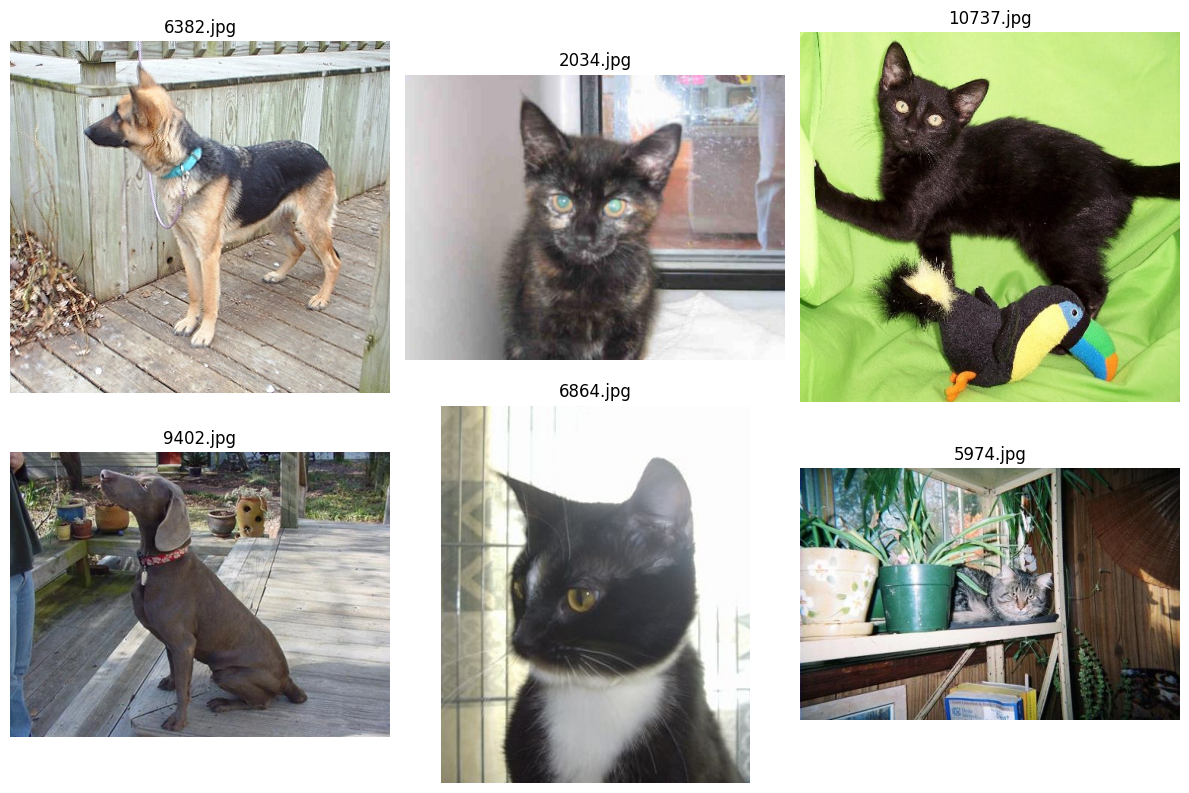

In [3]:
root = data_folder

# Get all images (.jpg and .jpeg) from subfolders
imgs = list(root.rglob("*.jpg")) + list(root.rglob("*.jpeg"))

# Guard against too few images
if len(imgs) < 6:
    print(f"Only {len(imgs)} images found, cannot sample 6.")
else:
    sampled = random.sample(imgs, 6)

    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(sampled, 1):
        img = Image.open(img_path)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
    plt.tight_layout()
    plt.show()


### Image Size Analysis
Before we resize the images, let's analyze the dataset qualities:
- Size
- Width
- Height


In [4]:
# Sample up to 3000 images
sample_size = min(3000, len(imgs))
sampled_imgs = random.sample(imgs, sample_size)

# Collect width & height metadata
img_meta = {str(f): imagesize.get(f) for f in sampled_imgs}

# Convert to DataFrame (correct orientation)
img_meta_df = (
    pd.DataFrame(list(img_meta.items()), columns=["FileName", "Size"])
    .assign(Width=lambda df: [s[0] for s in df["Size"]],
            Height=lambda df: [s[1] for s in df["Size"]],
            Aspect_Ratio=lambda df: round(df["Width"] / df["Height"], 2))
    .drop(columns=["Size"])
)

print(f"Total Nr of Images in the dataset: {len(img_meta_df)}")
img_meta_df.head()

Total Nr of Images in the dataset: 3000


,FileName,Width,Height,Aspect_Ratio
0,D:\GitHub\CatDog\data\Cat\5334.jpg,500,375,1.33
1,D:\GitHub\CatDog\data\Cat\2867.jpg,250,245,1.02
2,D:\GitHub\CatDog\data\Dog\9252.jpg,200,135,1.48
3,D:\GitHub\CatDog\data\Cat\1774.jpg,389,500,0.78
4,D:\GitHub\CatDog\data\Dog\7484.jpg,482,500,0.96


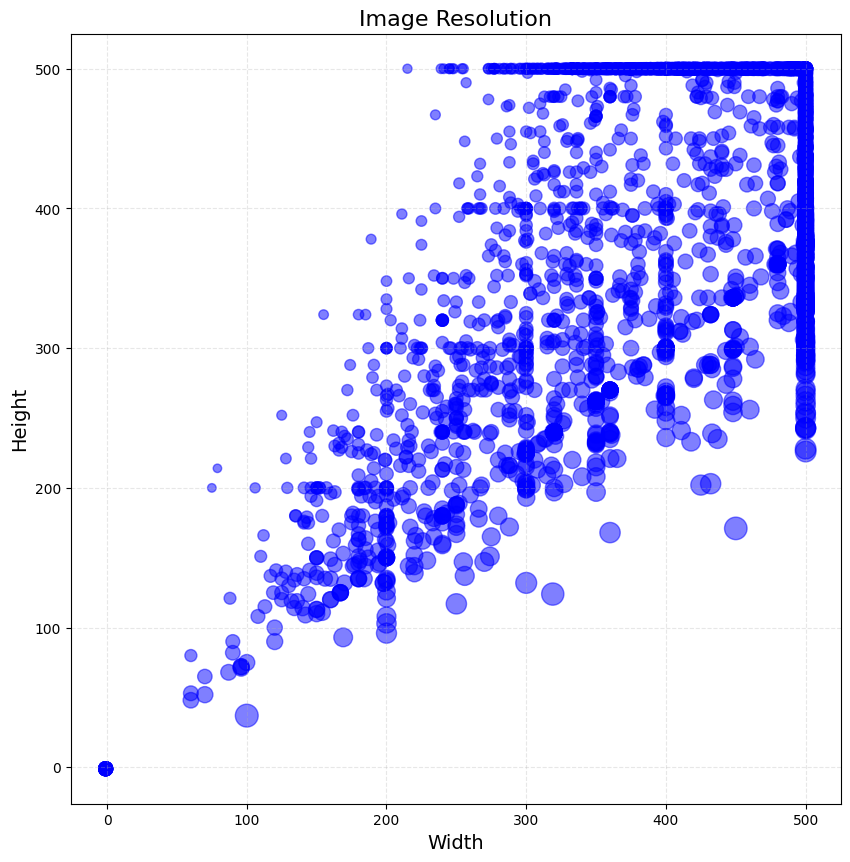

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

# Drop invalid aspect ratios to avoid scatter errors
valid_df = img_meta_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Aspect_Ratio"])

points = ax.scatter(
    valid_df["Width"],
    valid_df["Height"],
    color="blue",
    alpha=0.5,
    s=valid_df["Aspect_Ratio"] * 100,
    picker=True
)

ax.set_title("Image Resolution", fontsize=16)
ax.set_xlabel("Width", fontsize=14)
ax.set_ylabel("Height", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_aspect("equal", adjustable="box")
plt.show()

### Image Resolution Analysis
These results show us that many of the images have a quadratic form. We can resize them without much cropping or padding.

### Pixel Intensity Distribution
50 sampled images; 0=black, 255=white; it seems to be a normal distribution without missing ranges.


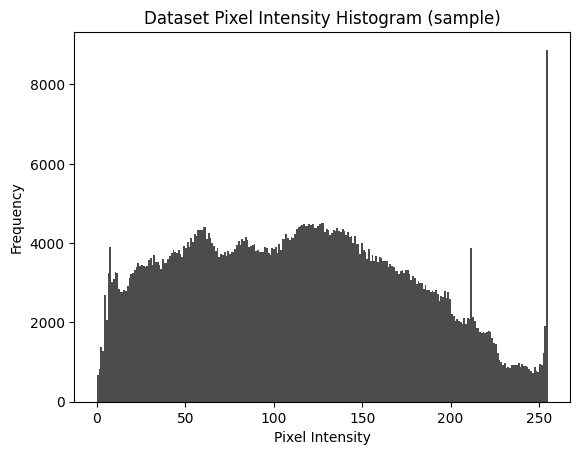

In [6]:
# Sample up to 50 images safely
sample_size = min(50, len(imgs))
sampled_hist_imgs = random.sample(imgs, sample_size)

all_pixels = []

for img_path in sampled_hist_imgs:
    try:
        img = Image.open(img_path).convert("L")
        # Optional: downscale large images to speed up histogram creation
        img = img.resize((128, 128))
        pixels = np.array(img).ravel()
        all_pixels.extend(pixels)
    except Exception as e:
        print(f"Skipping {img_path.name}: {e}")

plt.hist(all_pixels, bins=256, range=(0, 255), color='black', alpha=0.7)
plt.title("Dataset Pixel Intensity Histogram (sample)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

## 2. Data Preprocessing
### PyTorch Preprocessing Pipeline
Images are resized/cropped to 224x224. Augmentations are applied to the training set only.

Classes: ['cat', 'dog']
Class to index: {'cat': 0, 'dog': 1}
Train/Valid/Test sizes: 1000/200/200
Batch tensor shape: torch.Size([256, 3, 224, 224])


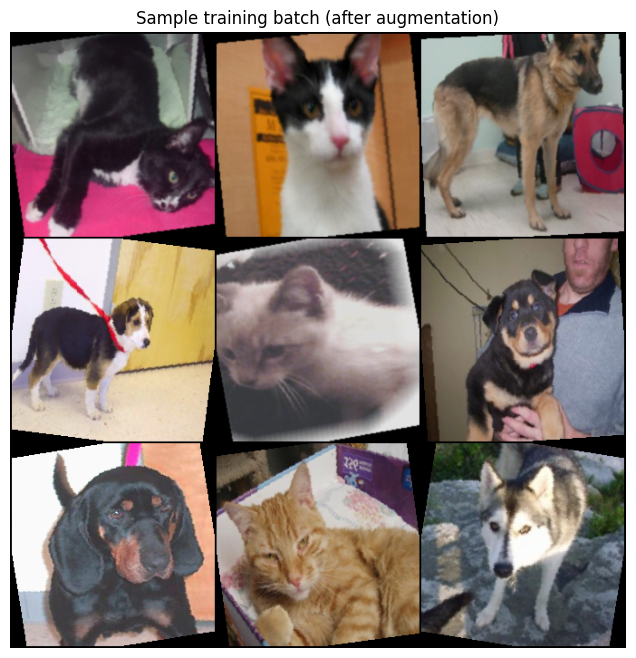

In [7]:
# Configuration parameters
BATCH_TRAIN = 256  # we can lower to 64–128 on CPU if it's slow
BATCH_VAL   = 256
IMG_SIZE    = 224
EPOCHS      = 60
PATIENCE    = 7
LR          = 3e-4
WEIGHT_DECAY= 1e-3
LABEL_SMOOTH= 0.05

# In notebooks on macOS/CPU, workers can cause hangs; keep 0 for stability
NUM_WORKERS = 0

# Normalization (ImageNet stats work well for RGB natural images)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# Data augmentation for training (gentler)
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.RandomRotation(10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    normalize,
])

# Validation/Test: no augmentation, deterministic
inference_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    normalize,
])

# Datasets
train_dir = data_folder / "train"
valid_dir = data_folder / "valid"
test_dir  = data_folder / "test"

train_ds = datasets.ImageFolder(str(train_dir), transform=train_transform)
valid_ds = datasets.ImageFolder(str(valid_dir), transform=inference_transform)
test_ds  = datasets.ImageFolder(str(test_dir),  transform=inference_transform)

# DataLoaders
pin_memory = torch.cuda.is_available()

common_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=pin_memory)
# Only set these when workers > 0 (otherwise DataLoader complains / may hang)
loader_extras = {}
if NUM_WORKERS > 0:
    loader_extras = dict(persistent_workers=True, prefetch_factor=4)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    **common_kwargs, **loader_extras
)
valid_loader = DataLoader(
    valid_ds, batch_size=BATCH_VAL, shuffle=False,
    **common_kwargs, **loader_extras
)
test_loader  = DataLoader(
    test_ds, batch_size=BATCH_VAL, shuffle=False,
    **common_kwargs, **loader_extras
)

print("Classes:", train_ds.classes)
print("Class to index:", train_ds.class_to_idx)
print(f"Train/Valid/Test sizes: {len(train_ds)}/{len(valid_ds)}/{len(test_ds)}")

# Visualize a training batch
images, labels = next(iter(train_loader))
print("Batch tensor shape:", images.shape)

# Convert back to [0,1] for display from normalized tensors
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

imgs_show = inv_normalize(images.clone()).clamp(0, 1)  # clamp for safe display
grid = make_grid(imgs_show[:9], nrow=3, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Sample training batch (after augmentation)")
plt.show()


### Preprocessing Adequacy Check

The current PyTorch preprocessing is appropriate for a Cats vs Dogs CNN:

- Deterministic validation/test pipeline: Resize(256) -> CenterCrop(224) -> ToTensor -> Normalize.
- Training-time augmentation: RandomResizedCrop, HorizontalFlip, small Rotation, ColorJitter, and GaussianBlur. These improve generalization without changing labels.
- Normalization: ImageNet mean/std, which is standard for RGB natural images. Alternatively, you can compute dataset-specific stats later.
- Batch visualization included to sanity-check augmentations and labels.


## 3. CNN: Model, Training, and Evaluation
### Model Architecture

In [8]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2), nn.Dropout(0.10),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2), nn.Dropout(0.20),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2), nn.Dropout(0.30),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.head(self.feat(x))

num_classes = len(train_ds.classes)
model = SimpleCNN(num_classes=num_classes).to(device)
print(model)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

SimpleCNN(
  (feat): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.1, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.2, inplac

### Training and Validation Process

In [9]:
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

# ---- AMP setup: enable only on CUDA ----
use_amp = (device.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def run_epoch(model, loader, criterion, device, train: bool):
    model.train() if train else model.eval()
    total_loss, total_acc, total_n = 0.0, 0.0, 0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)
            # autocast only when enabled; picks fp16 on cuda, bf16 on cpu if we enable it
            with torch.autocast(device_type=device.type, dtype=(torch.float16 if device.type == "cuda" else torch.bfloat16), enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
        else:
            with torch.no_grad():
                logits = model(x)
                loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits.detach(), y.detach()) * bs
        total_n    += bs

        del logits, loss

    return total_loss/total_n, total_acc/total_n

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state = None
no_improve = 0
start = perf_counter()

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, device, train=True)
    va_loss, va_acc = run_epoch(model, valid_loader, criterion, device, train=False)
    scheduler.step(va_loss)  # ReduceLROnPlateau on validation loss

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)

    torch.cuda.empty_cache()
    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f}, acc {tr_acc:.3f} | val loss {va_loss:.4f}, acc {va_acc:.3f}")

    # early stopping on val_acc
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement {PATIENCE} epochs).")
            break

end = perf_counter()

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Training finished in {(end-start):.1f}s. Best val acc: {best_val_acc:.3f}")

# --- Evaluate on TEST set and print % ---
model.eval()

@torch.no_grad()
def accuracy_on(loader):
    correct = total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
        del logits, preds, x, y
    torch.cuda.empty_cache()
    return correct / total if total else 0.0

test_acc = accuracy_on(test_loader)
val_acc  = accuracy_on(valid_loader)

print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Final Test Accuracy:       {test_acc*100:.2f}%")

C:\Users\fanni\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01 | train loss 0.6809, acc 0.550 | val loss 0.6940, acc 0.500
Epoch 02 | train loss 0.6638, acc 0.600 | val loss 0.6972, acc 0.500
Epoch 03 | train loss 0.6538, acc 0.613 | val loss 0.7028, acc 0.500
Epoch 04 | train loss 0.6431, acc 0.626 | val loss 0.7159, acc 0.500
Epoch 05 | train loss 0.6312, acc 0.648 | val loss 0.7449, acc 0.500
Epoch 06 | train loss 0.6326, acc 0.635 | val loss 0.7488, acc 0.500
Epoch 07 | train loss 0.6166, acc 0.661 | val loss 0.7356, acc 0.515
Epoch 08 | train loss 0.6043, acc 0.684 | val loss 0.7270, acc 0.530
Epoch 09 | train loss 0.6161, acc 0.675 | val loss 0.7171, acc 0.555
Epoch 10 | train loss 0.6063, acc 0.675 | val loss 0.7087, acc 0.580
Epoch 11 | train loss 0.6040, acc 0.696 | val loss 0.6819, acc 0.595
Epoch 12 | train loss 0.6009, acc 0.681 | val loss 0.6676, acc 0.605
Epoch 13 | train loss 0.6027, acc 0.690 | val loss 0.6644, acc 0.605
Epoch 14 | train loss 0.5996, acc 0.683 | val loss 0.6621, acc 0.610
Epoch 15 | train loss 0.5959, acc 

### Learning Curves Visualization

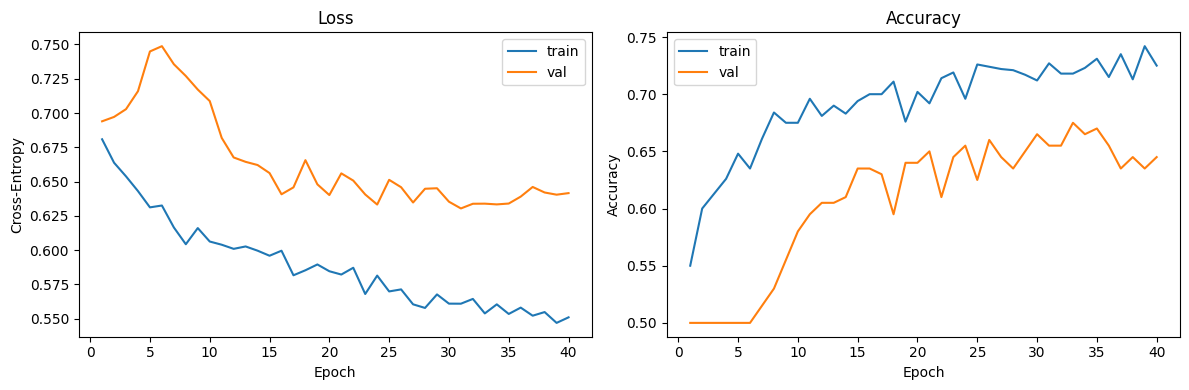

In [10]:
plt.figure(figsize=(12, 4))

# Define actual epoch range (important if early stopping occurred)
epochs = range(1, len(train_losses) + 1)

# --- Loss plot ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='train')
plt.plot(epochs, val_losses, label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy')
plt.legend()

# --- Accuracy plot ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='train')
plt.plot(epochs, val_accs, label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Test Set Evaluation and Predictions

Cat-only test accuracy: 0.830


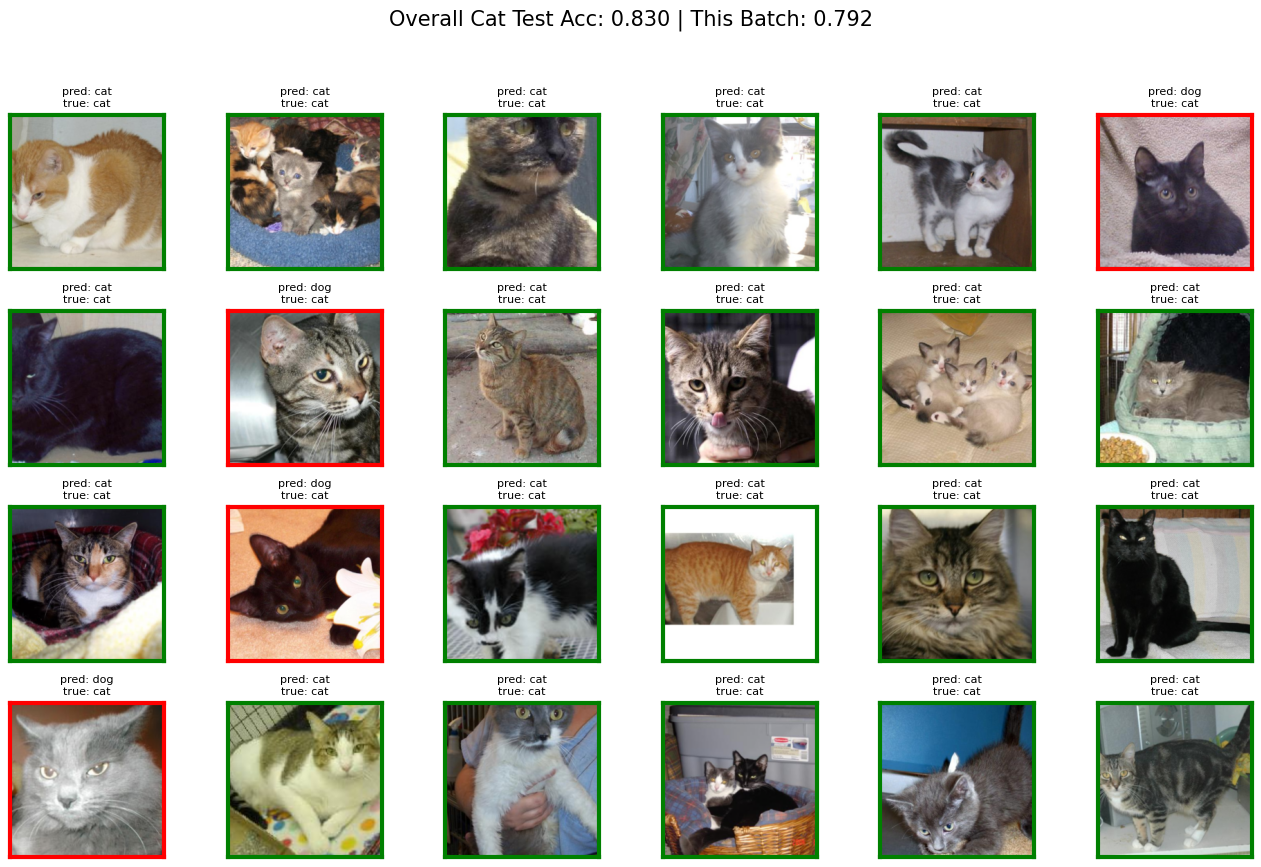

In [11]:
# ==== Visualize CAT images only ====

SHOW_RANDOM = True  # False = same pics every run

model.eval()
device = next(model.parameters()).device

# Reuse dataset from existing test_loader
test_ds = getattr(test_loader, "dataset", None)
assert test_ds is not None, "test_loader.dataset not found."

# Find the 'cat' class index robustly
classes = test_ds.classes
cat_idx_candidates = [i for i, c in enumerate(classes) if "cat" in c.lower()]
cat_idx = cat_idx_candidates[0] if cat_idx_candidates else (0 if len(classes) == 2 else 0)

# Build a DataLoader that samples ONLY cat images
cat_indices = [i for i, t in enumerate(getattr(test_ds, "targets", [])) if t == cat_idx]
assert len(cat_indices) > 0, "No cat images found in the test set."

cat_sampler = SubsetRandomSampler(cat_indices)
cat_loader = DataLoader(
    test_ds,
    batch_size=48,
    sampler=cat_sampler,
    num_workers=getattr(test_loader, "num_workers", 4),
    pin_memory=torch.cuda.is_available(),  # safer
)

# Inverse normalization
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# ---- Evaluate overall cat-only test accuracy ----
@torch.no_grad()
def cat_only_accuracy(model, loader, device, cat_idx):
    correct = total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).detach().cpu()
        y_cpu = y.detach().cpu()            
        correct += (preds == y_cpu).sum().item() 
        total += y_cpu.size(0)
        del logits, x
    torch.cuda.empty_cache()
    return correct / total if total else 0.0

cat_test_acc = cat_only_accuracy(model, cat_loader, device, cat_idx)
print(f"Cat-only test accuracy: {cat_test_acc:.3f}")

# ---- Visualize a single CATS-ONLY batch ----
images, labels = next(iter(cat_loader))  # DataLoader shuffle handles randomness

with torch.no_grad():
    logits = model(images.to(device, non_blocking=True))
    preds = torch.argmax(logits, dim=1).detach().cpu()

torch.cuda.empty_cache()

# Batch accuracy (cats only)
batch_acc = (preds == labels).float().mean().item()

# Prepare images for display
imgs_show = inv_normalize(images)
rows, cols = 4, 6   # 24 images grid
n_show = min(rows * cols, images.size(0))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
fig.suptitle(
    f"Overall Cat Test Acc: {cat_test_acc:.3f} | This Batch: {batch_acc:.3f}",
    fontsize=15
)
axes = np.array(axes).reshape(-1)
for i in range(n_show):
    ax = axes[i]
    ax.imshow(imgs_show[i].permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([])
    is_correct = (preds[i].item() == labels[i].item())
    color = 'green' if is_correct else 'red'
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(f"pred: {classes[preds[i]]}\ntrue: {classes[labels[i]]}", fontsize=8)

# Hide unused axes
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Dog-only test accuracy: 0.560


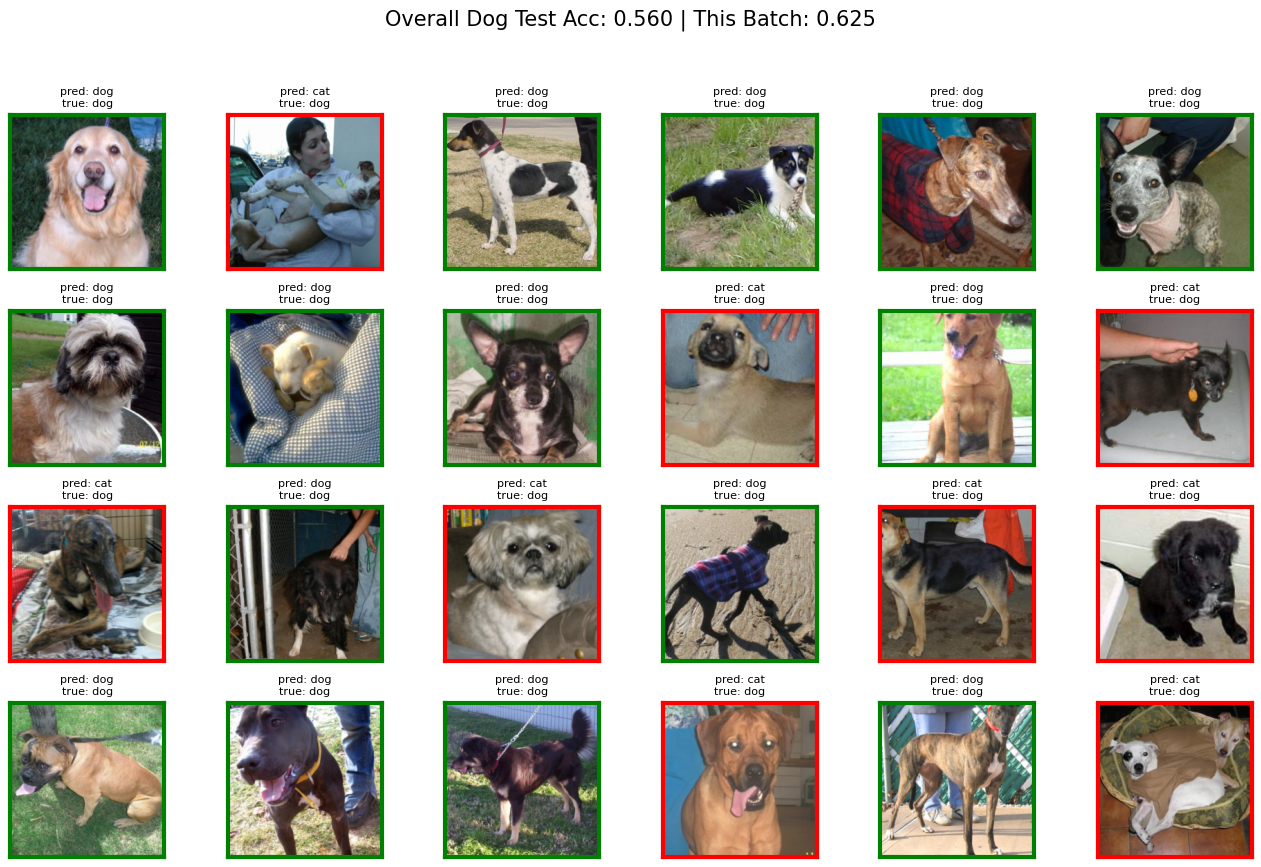

In [12]:
# ==== Visualize DOG images only ====

model.eval()
device = next(model.parameters()).device

# Reuse dataset from existing test_loader
test_ds = getattr(test_loader, "dataset", None)
assert test_ds is not None, "test_loader.dataset not found."

# Find the 'dog' class index robustly
classes = test_ds.classes
dog_idx_candidates = [i for i, c in enumerate(classes) if "dog" in c.lower()]
dog_idx = dog_idx_candidates[0] if dog_idx_candidates else (1 if len(classes) == 2 else 0)

# Build a DataLoader that samples ONLY dog images
dog_indices = [i for i, t in enumerate(getattr(test_ds, "targets", [])) if t == dog_idx]
assert len(dog_indices) > 0, "No dog images found in the test set."

dog_sampler = SubsetRandomSampler(dog_indices)
dog_loader = DataLoader(
    test_ds,
    batch_size=48,                             # can be tweaked
    sampler=dog_sampler,
    num_workers=getattr(test_loader, "num_workers", 4),
    pin_memory=torch.cuda.is_available(),      # safer on CPU-only
)

# Inverse normalization
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# ---- Evaluate overall dog-only test accuracy ----
@torch.no_grad()
def dog_only_accuracy(model, loader, device, dog_idx):
    correct = total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).detach().cpu()
        y_cpu = y.detach().cpu()            
        correct += (preds == y_cpu).sum().item()  
        total += y_cpu.size(0)
        del logits, x
    torch.cuda.empty_cache()
    return correct / total if total else 0.0

dog_test_acc = dog_only_accuracy(model, dog_loader, device, dog_idx)
print(f"Dog-only test accuracy: {dog_test_acc:.3f}")

# ---- Visualize a single DOGS-ONLY batch ----
images, labels = next(iter(dog_loader))  # SubsetRandomSampler provides randomness

with torch.no_grad():
    logits = model(images.to(device, non_blocking=True))
    preds = torch.argmax(logits, dim=1).detach().cpu()
torch.cuda.empty_cache()

# Batch accuracy (dogs only)
batch_acc = (preds == labels).float().mean().item()

# Prepare images for display
imgs_show = inv_normalize(images)
rows, cols = 4, 6   # 24 images grid
n_show = min(rows * cols, images.size(0))

fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
fig.suptitle(
    f"Overall Dog Test Acc: {dog_test_acc:.3f} | This Batch: {batch_acc:.3f}",
    fontsize=15
)
axes = np.array(axes).reshape(-1)
for i in range(n_show):
    ax = axes[i]
    ax.imshow(imgs_show[i].permute(1, 2, 0).numpy())
    ax.set_xticks([]); ax.set_yticks([])
    is_correct = (preds[i].item() == labels[i].item())
    color = 'green' if is_correct else 'red'
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(f"pred: {classes[preds[i]]}\ntrue: {classes[labels[i]]}", fontsize=8)

# Hide unused axes
for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

TEST accuracy: 0.695
              precision    recall  f1-score   support

         cat       0.65      0.83      0.73       100
         dog       0.77      0.56      0.65       100

    accuracy                           0.69       200
   macro avg       0.71      0.70      0.69       200
weighted avg       0.71      0.69      0.69       200



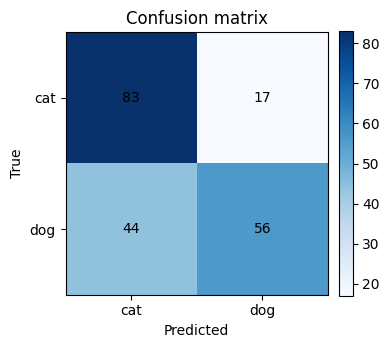

In [13]:

model.eval()
all_y, all_p = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_p.append(pred)
        all_y.append(y.detach().cpu().numpy())
        del logits, x, y
    torch.cuda.empty_cache()

y_true = np.concatenate(all_y)
y_pred = np.concatenate(all_p)

print("TEST accuracy:", (y_true == y_pred).mean())
print(classification_report(y_true, y_pred, target_names=test_loader.dataset.classes))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion matrix')
ax.set_xticks(range(len(cm))); ax.set_yticks(range(len(cm)))
ax.set_xticklabels(test_loader.dataset.classes); ax.set_yticklabels(test_loader.dataset.classes)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()